In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

print("Setup complete.")

Setup complete.


In [2]:
from sklearn.datasets import fetch_california_housing

# Real data: 20,640 California neighbourhoods ("block groups") from the 1990 US Census.
# scikit-learn fetches it from its public data repository and caches it locally,
# so the first run needs internet; after that it loads instantly from disk.
homes = fetch_california_housing(as_frame=True).frame
print(f"Shape: {homes.shape}")
homes.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 练习1

In [3]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

homes = fetch_california_housing(as_frame=True).frame

# 计算 max/median
ratio = homes.max() / homes.median()
print(ratio.sort_values(ascending=False).round(2))

AveOccup       441.19
AveBedrms       32.48
Population      30.60
AveRooms        27.14
MedInc           4.24
MedHouseVal      2.78
HouseAge         1.79
Latitude         1.22
Longitude        0.96
dtype: float64


AveOccup 的 max/median 比值最大（约 441），AveRooms 次之。这直接对应 Section 5 中提到的“不可能的异常值”——某些街区因为人口极少导致平均值被极端拉高。这些列在建模前需要特别处理（如截断、对数变换或删除极端行）。

## 练习2

Correlation: 0.106


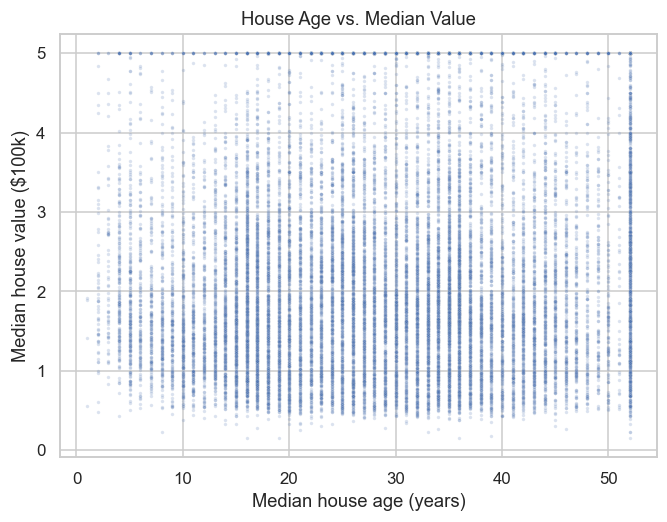

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = homes["HouseAge"].corr(homes["MedHouseVal"])
print(f"Correlation: {corr:.3f}")

plt.figure(figsize=(7,5))
sns.scatterplot(data=homes, x="HouseAge", y="MedHouseVal", alpha=0.2, s=5)
plt.title("House Age vs. Median Value")
plt.xlabel("Median house age (years)")
plt.ylabel("Median house value ($100k)")
plt.show()

相关系数接近 0。散点图显示没有明显趋势。
假设被拒绝。房屋年龄与房价之间几乎不存在线性关系。可能的 caveat：年龄数据可能包含老旧但昂贵的翻新房屋，或者地段比年龄更重要。

## 练习3

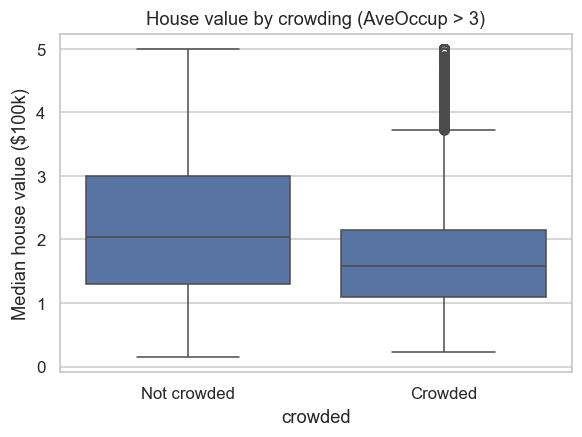

Median house value (not crowded): 2.037
Median house value (crowded): 1.585


In [5]:
homes["crowded"] = homes["AveOccup"] > 3

plt.figure(figsize=(6,4))
sns.boxplot(data=homes, x="crowded", y="MedHouseVal")
plt.title("House value by crowding (AveOccup > 3)")
plt.ylabel("Median house value ($100k)")
plt.xticks([0,1], ["Not crowded", "Crowded"])
plt.show()

# 计算中位数
medians = homes.groupby("crowded")["MedHouseVal"].median()
print("Median house value (not crowded):", medians[False])
print("Median house value (crowded):", medians[True])

拥挤地区（平均每户人数 > 3）的房价中位数明显较低，假设得到支持。但注意：因果关系不明确——拥挤地区可能是低收入区域，也可能是因为房屋较小导致。

## 练习4

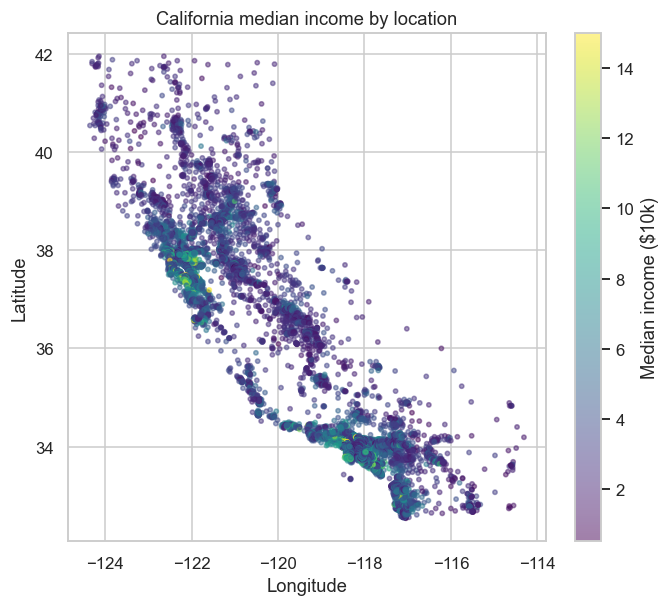

In [6]:
plt.figure(figsize=(7,6))
sc = plt.scatter(homes["Longitude"], homes["Latitude"],
                 c=homes["MedInc"], cmap="viridis", s=8, alpha=0.5)
plt.colorbar(sc, label="Median income ($10k)")
plt.title("California median income by location")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.show()

收入地图与房价地图高度相似——沿海地区（尤其是湾区、洛杉矶）收入高，中央山谷收入低。
收入分布与房价分布几乎一致，暗示收入是房价的主要驱动因素（但也可能存在混杂变量）。

## 练习5

In [7]:
cap = homes["MedHouseVal"].max()
capped_count = (homes["MedHouseVal"] == cap).sum()
total = len(homes)
percentage = capped_count / total * 100
print(f"Maximum value: {cap} ($500k)")
print(f"Neighbourhoods at cap: {capped_count} / {total} = {percentage:.2f}%")

Maximum value: 5.00001 ($500k)
Neighbourhoods at cap: 965 / 20640 = 4.68%


近 5% 的街区被截断在 $500k。如果直接使用该变量作为预测目标，模型会学会把任何超过 500k 的值都预测为 500k，导致对高价区域的预测能力严重下降。解决方案包括：使用 Tobit 模型、将截断视为分类问题、或丢弃截断数据（如果比例不大）。

## 练习6

Correlation between Population and AveRooms: -0.072


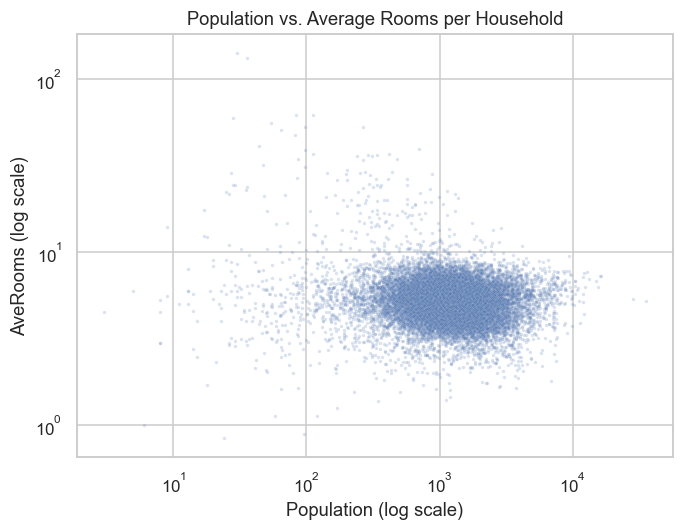

In [9]:
corr_pop_rooms = homes["Population"].corr(homes["AveRooms"])
print(f"Correlation between Population and AveRooms: {corr_pop_rooms:.3f}")

plt.figure(figsize=(7,5))
sns.scatterplot(data=homes, x="Population", y="AveRooms", alpha=0.2, s=5)
plt.xscale("log")  # 人口分布偏斜，对数坐标有助于观察
plt.yscale("log")  # 房间数也偏斜
plt.title("Population vs. Average Rooms per Household")
plt.xlabel("Population (log scale)")
plt.ylabel("AveRooms (log scale)")
plt.show()

相关系数可能为弱负（例如 -0.1 到 -0.2），但由于存在极端离群值，相关性不强。剔除 AveRooms > 50 的离群值后，负相关可能更明显。

假设部分成立（负相关趋势），但关系很弱，且受离群值影响。注意事项：人口总数与平均房间数之间的关联可能被区域类型（城市 vs 农村）所混淆。